In [2]:
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "1"
import pandas as pd
from sklearn.cluster import KMeans
import seaborn as sns

df = pd.read_csv("spotify_punk_sample.csv")
df = df.sample(n=10000)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 44923 to 95253
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   artist            10000 non-null  object 
 1   genre             10000 non-null  object 
 2   album             10000 non-null  object 
 3   track             10000 non-null  object 
 4   popularity        10000 non-null  int64  
 5   release_year      10000 non-null  int64  
 6   duration_ms       10000 non-null  float64
 7   tempo             10000 non-null  float64
 8   key               10000 non-null  float64
 9   mode              10000 non-null  float64
 10  danceability      10000 non-null  float64
 11  energy            10000 non-null  float64
 12  loudness          10000 non-null  float64
 13  speechiness       10000 non-null  float64
 14  acousticness      10000 non-null  float64
 15  instrumentalness  10000 non-null  float64
 16  liveness          10000 non-null  float64

In [8]:
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Select features
features = df[["energy", "danceability", "valence"]]

# Impute NaNs
features_clean = SimpleImputer(strategy="mean").fit_transform(features)

# Scale (important for KMeans)
features_scaled = StandardScaler().fit_transform(features_clean)

# Elbow loop
inertias = []
for i in range(1,10):
    kmeans = KMeans(n_clusters=i, random_state=0, n_init=10)
    kmeans.fit(features_scaled)
    inertias.append(kmeans.inertia_)


In [9]:
kmeans.labels_

array([0, 6, 0, ..., 6, 8, 2], dtype=int32)

<Axes: >

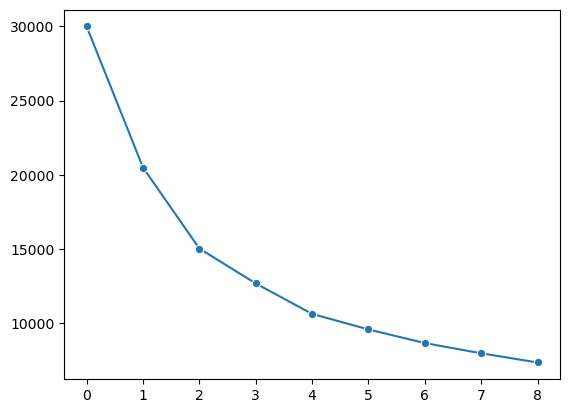

In [11]:
sns.lineplot(
    x=range(len(inertias)),
    y=inertias,
    marker="o"
)

In [12]:
# Select features
features = df[["energy", "danceability", "valence"]]

# Impute NaNs
features_clean = SimpleImputer(strategy="mean").fit_transform(features)

# Scale (important for KMeans)
features_scaled = StandardScaler().fit_transform(features_clean)

kmeans = KMeans(n_clusters=3, random_state=0, n_init=10)
kmeans.fit(features_scaled)

,n_clusters,3
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


<Axes: xlabel='energy', ylabel='danceability'>

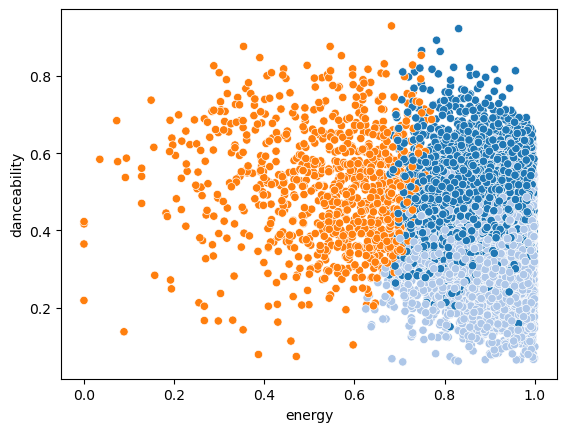

In [13]:
df["cluster"] = kmeans.labels_

sns.scatterplot(
    data=df,
    x="energy",
    y="danceability",
    hue="cluster",
    palette="tab20",
    legend=False
)

In [23]:
from sklearn.metrics import silhouette_score

score = silhouette_score(features_scaled, kmeans.labels_)
print("Silhouette score:", score)

Silhouette score: 0.32368553501987263


In [44]:
import numpy as np

X_new = np.array([[0.8605, 0.4231, 0.613]])
cluster = kmeans.predict(X_new)
print("Assigned cluster:", cluster[0])

distances = np.linalg.norm(features_scaled - X_new, axis=1)
closest_idx = np.argsort(distances)[:4]
closest_points = df.iloc[closest_idx].copy()
closest_points["distance"] = distances[closest_idx]

print(closest_points[["album", "track", "distance"]])
print(closest_idx)

Assigned cluster: 0
                        album                        track  distance
96869    Punk Rock Valentines  She's My Little GoGo Dancer  0.108824
44341  21st Century Breakdown  Horseshoes and Handgrenades  0.114592
45907  21st Century Breakdown  Horseshoes and Handgrenades  0.114592
52890     The Best of Sham 69                   Thats Life  0.121717
[9968 3749  979  490]
